### 資料前處理與特徵工程

清理髒資料：處理空白值（NA）、統一文字格式（如移除多餘空白、修正錯字）、剔除不合邏輯的資料（例如：在公司年資大於實際年齡）。

處理極端值（Outliers）：找出薪資過高或過低的不合理資料，並將其截斷（Capping）在合理範圍內，避免未來的模型被極端值拉偏。

創造客觀能力/狀態指標（特徵工程）：利用結構方程模型（SEM）將原本分散的問卷分數（環境滿意度、工作與生活平衡等），統合成一個更有代表性的潛在變數（例如 Experience 體驗分數），這些經過清理和計算的指標，就是為您後續建立「客觀能力值」做準備。

In [3]:
pip install semopy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 11.5 MB/s  0:00:00eta 0:00:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for semopy: filename=semopy-2.3.11-py3-none-any.whl size=1659769 sha256=31c222a0669976ef96aa36a2ec4ce3fa51851e35f675dd94478bb4ae14f7a2ab
  Stored in directory: /Users/belindaty.yu/Library/Caches/pip/wheels/c6/24/8b/be911b059a61f490f38425eb19bf2fed470a5ead97228e8255
Successfully built semopy
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [semopy]2m1/2 [semopy]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [5]:
pip install factor_analyzer

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for factor_analyzer: filename=factor_analyzer-0.5.1-py2.py3-none-any.whl size=42655 sha256=adf295e79eaf702dd85589764782393e1f25f24ea3f2032cbde7b0f32daa8010
  Stored in directory: /Users/belindaty.yu/Library/Caches/pip/wheels/a2/af/06/f4d4ed4d9d714fda437fb1583629417319603c2266e7b233cc
Successfully built factor_analyzer

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from semopy import Model
from factor_analyzer import ConfirmatoryFactorAnalyzer
from factor_analyzer import FactorAnalyzer
from scipy import stats
import shap
from scipy.optimize import linprog
import warnings
warnings.filterwarnings("ignore")

In [7]:
data=pd.read_csv('/Users/belindaty.yu/Desktop/碩士/論文/論文資料/HRDataset_v2/Employee.csv')
EducationLevel=pd.read_csv('/Users/belindaty.yu/Desktop/碩士/論文/論文資料/HRDataset_v2/EducationLevel.csv')

In [8]:
data.head(15)

,EmployeeID,FirstName,LastName,Gender,Age,BusinessTravel,Department,DistanceFromHome (KM),State,Ethnicity,...,MaritalStatus,Salary,StockOptionLevel,OverTime,HireDate,Attrition,YearsAtCompany,YearsInMostRecentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,3012-1A41,Leonelle,Simco,Female,30,Some Travel,Sales,27,IL,White,...,Divorced,102059,1,No,2012-01-03,No,10,4,9,7
1,CBCB-9C9D,Leonerd,Aland,Male,38,Some Travel,Sales,23,CA,White,...,Single,157718,0,Yes,2012-01-04,No,10,6,10,0
2,95D7-1CE9,Ahmed,Sykes,Male,43,Some Travel,Human Resources,29,CA,Asian or Asian American,...,Married,309964,1,No,2012-01-04,No,10,6,10,8
3,47A0-559B,Ermentrude,Berrie,Non-Binary,39,Some Travel,Technology,12,IL,White,...,Married,293132,0,No,2012-01-05,No,10,10,10,0
4,42CC-040A,Stace,Savege,Female,29,Some Travel,Human Resources,29,CA,White,...,Single,49606,0,No,2012-01-05,Yes,6,1,1,6
5,C219-6C2E,Clerkclaude,Hinkins,Male,34,Some Travel,Sales,30,NY,Mixed or multiple ethnic groups,...,Divorced,133468,1,No,2012-01-05,No,10,3,7,9
6,D906-B674,Uta,Melmar,Female,42,No Travel,Technology,45,NY,Black or African American,...,Married,259284,1,No,2012-01-09,No,10,2,6,6
7,3C7D-86ED,Joyan,Brason,Female,40,Some Travel,Sales,3,CA,Native Hawaiian,...,Divorced,104426,1,No,2012-01-11,No,10,3,4,6
8,3D71-8DC2,Alix,Blazejewski,Male,38,Some Travel,Sales,20,IL,Black or African American,...,Married,147098,1,No,2012-01-11,No,10,5,8,2
9,5476-CA0D,Kayley,Snoad,Female,31,Frequent Traveller,Technology,4,NY,Native Hawaiian,...,Single,69747,0,No,2012-01-12,Yes,6,5,5,1


In [9]:
data.shape

(1470, 23)

In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   EmployeeID               1470 non-null   object
 1   FirstName                1470 non-null   object
 2   LastName                 1470 non-null   object
 3   Gender                   1470 non-null   object
 4   Age                      1470 non-null   int64 
 5   BusinessTravel           1470 non-null   object
 6   Department               1470 non-null   object
 7   DistanceFromHome (KM)    1470 non-null   int64 
 8   State                    1470 non-null   object
 9   Ethnicity                1470 non-null   object
 10  Education                1470 non-null   int64 
 11  EducationField           1470 non-null   object
 12  JobRole                  1470 non-null   object
 13  MaritalStatus            1470 non-null   object
 14  Salary                   1470 non-null  

In [ ]:
data.columns

Index(['EmployeeID', 'FirstName', 'LastName', 'Gender', 'Age',
       'BusinessTravel', 'Department', 'DistanceFromHome (KM)', 'State',
       'Ethnicity', 'Education', 'EducationField', 'JobRole', 'MaritalStatus',
       'Salary', 'StockOptionLevel', 'OverTime', 'HireDate', 'Attrition',
       'YearsAtCompany', 'YearsInMostRecentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [ ]:
data.describe()

,Age,DistanceFromHome (KM),Education,Salary,StockOptionLevel,YearsAtCompany,YearsInMostRecentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,28.989796,22.502721,2.912925,112956.497959,0.793878,4.562585,2.293197,3.440816,2.239456
std,7.993055,12.811124,1.024165,103342.889222,0.852077,3.288048,2.539093,2.945194,2.505774
min,18.000000,1.000000,1.000000,20387.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,23.000000,12.000000,2.000000,43580.500000,0.000000,2.000000,0.000000,1.000000,0.000000
50%,26.000000,22.000000,3.000000,71199.500000,1.000000,4.000000,1.000000,3.000000,1.000000
75%,34.000000,33.000000,4.000000,142055.750000,1.000000,7.000000,4.000000,6.000000,4.000000
max,51.000000,45.000000,5.000000,547204.000000,3.000000,10.000000,10.000000,10.000000,10.000000


In [ ]:
data.isna().sum()

EmployeeID                 0
FirstName                  0
LastName                   0
Gender                     0
Age                        0
BusinessTravel             0
Department                 0
DistanceFromHome (KM)      0
State                      0
Ethnicity                  0
Education                  0
EducationField             0
JobRole                    0
MaritalStatus              0
Salary                     0
StockOptionLevel           0
OverTime                   0
HireDate                   0
Attrition                  0
YearsAtCompany             0
YearsInMostRecentRole      0
YearsSinceLastPromotion    0
YearsWithCurrManager       0
dtype: int64

there is no duplicates

In [ ]:
data.duplicated().sum()

0

In [ ]:
# Replacing Invalid or Missing Values
data.replace([' ', 'NA', 'N/A', 'na'], pd.NA, inplace=True)

In [ ]:
# Education
data['Education'] = data['Education'].replace(
    EducationLevel.set_index('EducationLevelID')['EducationLevel']
)

In [ ]:
data[['Education' ]].head()

,Education
0,Doctorate
1,Masters
2,Masters
3,Bachelors
4,High School


In [ ]:
data.head(15)

,EmployeeID,FirstName,LastName,Gender,Age,BusinessTravel,Department,DistanceFromHome (KM),State,Ethnicity,...,MaritalStatus,Salary,StockOptionLevel,OverTime,HireDate,Attrition,YearsAtCompany,YearsInMostRecentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,3012-1A41,Leonelle,Simco,Female,30,Some Travel,Sales,27,IL,White,...,Divorced,102059,1,No,2012-01-03,No,10,4,9,7
1,CBCB-9C9D,Leonerd,Aland,Male,38,Some Travel,Sales,23,CA,White,...,Single,157718,0,Yes,2012-01-04,No,10,6,10,0
2,95D7-1CE9,Ahmed,Sykes,Male,43,Some Travel,Human Resources,29,CA,Asian or Asian American,...,Married,309964,1,No,2012-01-04,No,10,6,10,8
3,47A0-559B,Ermentrude,Berrie,Non-Binary,39,Some Travel,Technology,12,IL,White,...,Married,293132,0,No,2012-01-05,No,10,10,10,0
4,42CC-040A,Stace,Savege,Female,29,Some Travel,Human Resources,29,CA,White,...,Single,49606,0,No,2012-01-05,Yes,6,1,1,6
5,C219-6C2E,Clerkclaude,Hinkins,Male,34,Some Travel,Sales,30,NY,Mixed or multiple ethnic groups,...,Divorced,133468,1,No,2012-01-05,No,10,3,7,9
6,D906-B674,Uta,Melmar,Female,42,No Travel,Technology,45,NY,Black or African American,...,Married,259284,1,No,2012-01-09,No,10,2,6,6
7,3C7D-86ED,Joyan,Brason,Female,40,Some Travel,Sales,3,CA,Native Hawaiian,...,Divorced,104426,1,No,2012-01-11,No,10,3,4,6
8,3D71-8DC2,Alix,Blazejewski,Male,38,Some Travel,Sales,20,IL,Black or African American,...,Married,147098,1,No,2012-01-11,No,10,5,8,2
9,5476-CA0D,Kayley,Snoad,Female,31,Frequent Traveller,Technology,4,NY,Native Hawaiian,...,Single,69747,0,No,2012-01-12,Yes,6,5,5,1


In [ ]:
# replacing the data type to category
cat_cols = [
    'BusinessTravel', 'Department', 'EducationField', 'JobRole',
    'MaritalStatus', 'OverTime', 'Attrition', 'Gender', 'State', 'Ethnicity',
     'Education'
]

for col in cat_cols:
    if col in data.columns:
        data[col] = data[col].astype('category')

In [ ]:
# check uniqueness
for col in cat_cols:
    print('-'*30)
    print(col)
    print(data[col].unique())

------------------------------
BusinessTravel
['Some Travel', 'No Travel ', 'Frequent Traveller']
Categories (3, object): ['Frequent Traveller', 'No Travel ', 'Some Travel']
------------------------------
Department
['Sales', 'Human Resources', 'Technology']
Categories (3, object): ['Human Resources', 'Sales', 'Technology']
------------------------------
EducationField
['Marketing', 'Marketing ', 'Computer Science', 'Technical Degree', 'Information Systems', 'Other', 'Economics', 'Human Resources', 'Business Studies']
Categories (9, object): ['Business Studies', 'Computer Science', 'Economics', 'Human Resources', ..., 'Marketing', 'Marketing ', 'Other', 'Technical Degree']
------------------------------
JobRole
['Sales Executive', 'HR Business Partner', 'Engineering Manager', 'Recruiter', 'Data Scientist', ..., 'Senior Software Engineer', 'Sales Representative', 'Analytics Manager', 'HR Executive', 'HR Manager']
Length: 13
Categories (13, object): ['Analytics Manager', 'Data Scientist'

In [ ]:
data['Ethnicity'].unique()

['White', 'Asian or Asian American', 'Mixed or multiple ethnic groups', 'Black or African American', 'Native Hawaiian ', 'Other ', 'American Indian or Alaska Native']
Categories (7, object): ['American Indian or Alaska Native', 'Asian or Asian American', 'Black or African American', 'Mixed or multiple ethnic groups', 'Native Hawaiian ', 'Other ', 'White']

In [ ]:
data['Ethnicity'] = data['Ethnicity'].replace('Asian or Asian American', 'Asian')
data['Ethnicity'] = data['Ethnicity'].replace('Mixed or multiple ethnic groups', 'خ')
data['Ethnicity'] = data['Ethnicity'].replace('Black or African American', 'Black')
data['Ethnicity'] = data['Ethnicity'].replace('American Indian or Alaska Native', 'Native Americain')

In EducationField: there are 'Marketing' and 'Marketing ' (with an empty space)

In [ ]:
data['EducationField'] = data['EducationField'].replace('Marketing ', 'Marketing')

In [ ]:
# replacing the data type to datatime
data['HireDate'] = pd.to_datetime(data['HireDate'], errors='coerce')
# data['ReviewDate'] = pd.to_datetime(data['ReviewDate'], errors='coerce')

In [ ]:
# Removing Extra Spaces from Column Names and Text Fields
data.columns = data.columns.str.strip()

text_columns = data.select_dtypes(include='object').columns
data[text_columns] = data[text_columns].apply(lambda x: x.str.strip())

In [ ]:
# Removing Logically Inconsistent Records
data = data[
    (data['YearsWithCurrManager'] <= data['YearsAtCompany']) &
    (data['YearsSinceLastPromotion'] <= data['YearsAtCompany'])]

data = data[data['YearsAtCompany'] <= data['Age']]

In [ ]:
# Extracting Year from Review Date
data['ReviewYear'] = data['HireDate'].dt.year

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1470 entries, 0 to 1469
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   EmployeeID               1470 non-null   object        
 1   FirstName                1470 non-null   object        
 2   LastName                 1470 non-null   object        
 3   Gender                   1470 non-null   category      
 4   Age                      1470 non-null   int64         
 5   BusinessTravel           1470 non-null   category      
 6   Department               1470 non-null   category      
 7   DistanceFromHome (KM)    1470 non-null   int64         
 8   State                    1470 non-null   category      
 9   Ethnicity                1470 non-null   category      
 10  Education                1470 non-null   category      
 11  EducationField           1470 non-null   category      
 12  JobRole                  1470 non-

In [ ]:
# check for outliers 
numeric_cols = data.select_dtypes(include=['int64', 'float64']).columns
for col in numeric_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)]
    
    if len(outliers) > 0:
        print(f"\n🔹 Column: {col}")
        print(f"   Number of Outliers: {len(outliers)}")
    else :
        print("No Outliers")


🔹 Column: Age
   Number of Outliers: 1
No Outliers

🔹 Column: Salary
   Number of Outliers: 124

🔹 Column: StockOptionLevel
   Number of Outliers: 85
No Outliers
No Outliers
No Outliers
No Outliers
No Outliers


In [ ]:
data[['YearsInMostRecentRole']].describe()

,YearsInMostRecentRole
count,1470.000000
mean,2.293197
std,2.539093
min,0.000000
25%,0.000000
50%,1.000000
75%,4.000000
max,10.000000


In [ ]:
def experience_level(x):
    if x < 2:
        return 'Junior'
    elif x < 5:
        return 'Mid'
    else:
        return 'Senior'

data['ExperienceLevel'] = data['YearsInMostRecentRole'].apply(experience_level)

In [ ]:
# Detect and Count Salary Outliers Before Capping (Grouped by Year, Job Role, and Experience Level)

outliers_before = []

for (year, role, exp), group in data.groupby(['ReviewYear', 'JobRole', 'ExperienceLevel']):
    Q1 = group['Salary'].quantile(0.25)
    Q3 = group['Salary'].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    group_outliers = group[(group['Salary'] < lower) | (group['Salary'] > upper)]
    outliers_before.append(group_outliers)

outliers_before_df = pd.concat(outliers_before)
num_outliers_before = len(outliers_before_df)
print(f"{num_outliers_before}")

77


In [ ]:
# Apply Contextual Capping to Adjust Salary Outliers (Grouped by Year, Job Role, and Experience Level)

data_capped = data.copy()

for (year, role, exp), group in data.groupby(['ReviewYear', 'JobRole', 'ExperienceLevel']):
    Q1 = group['Salary'].quantile(0.25)
    Q3 = group['Salary'].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    data_capped.loc[group.index, 'New_Salary'] = group['Salary'].clip(lower, upper)


In [ ]:
# Detect and Count Salary Outliers After Capping (Grouped by Year, Job Role, and Experience Level)

outliers_after = []

for (year, role, exp), group in data_capped.groupby(['ReviewYear', 'JobRole', 'ExperienceLevel']):
    Q1 = group['New_Salary'].quantile(0.25)
    Q3 = group['New_Salary'].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    group_outliers = group[(group['New_Salary'] < lower) | (group['New_Salary'] > upper)]
    outliers_after.append(group_outliers)

remaining_outliers = pd.concat(outliers_after)
num_outliers_after = len(remaining_outliers)
print(f"{num_outliers_after}")

4


In [ ]:
remaining_outliers[['EmployeeID', 'ReviewYear', 'JobRole', 'ExperienceLevel', 'YearsInMostRecentRole', 'New_Salary']].sort_values('New_Salary', ascending=False).head(20)

,EmployeeID,ReviewYear,JobRole,ExperienceLevel,YearsInMostRecentRole,New_Salary
752,E73A-F20A,2017,Machine Learning Engineer,Mid,3,164220.250
203,F3CD-9B5B,2013,Sales Representative,Junior,0,78967.500
390,C95C-CE06,2014,Sales Representative,Senior,6,69131.875
1211,1787-DF90,2021,Sales Representative,Junior,1,63508.500


In [ ]:
indices = remaining_outliers[['EmployeeID', 'ReviewYear', 'JobRole', 'ExperienceLevel', 'YearsInMostRecentRole', 'New_Salary']].sort_values('New_Salary', ascending=False).head(20).index

indices

Int64Index([752, 203, 390, 1211], dtype='int64')

In [ ]:
print(f"Before {data_capped.shape}")
data_capped.drop(index=indices, inplace=True)
print(f"After {data_capped.shape}")

Before (1470, 26)
After (1466, 26)


In [ ]:
data_capped.to_csv('/Users/belindaty.yu/Desktop/碩士/論文/論文資料/HRDataset_v2/HR_Cleaned.csv', index=False)

In [ ]:
#載入績效資料與特徵工程
df = pd.read_csv(r'/Users/belindaty.yu/Desktop/碩士/論文/論文資料/HRDataset_v2/PerformanceRating.csv')

In [ ]:
df.head()

,PerformanceID,EmployeeID,ReviewDate,EnvironmentSatisfaction,JobSatisfaction,RelationshipSatisfaction,TrainingOpportunitiesWithinYear,TrainingOpportunitiesTaken,WorkLifeBalance,SelfRating,ManagerRating
0,PR01,79F7-78EC,1/2/2013,5,4,5,1,0,4,4,4
1,PR02,B61E-0F26,1/3/2013,5,4,4,1,3,4,4,3
2,PR03,F5E3-48BB,1/3/2013,3,4,5,3,2,3,5,4
3,PR04,0678-748A,1/4/2013,5,3,2,2,0,2,3,2
4,PR05,541F-3E19,1/4/2013,5,2,3,1,0,4,4,3


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6709 entries, 0 to 6708
Data columns (total 11 columns):
 #   Column                           Non-Null Count  Dtype 
---  ------                           --------------  ----- 
 0   PerformanceID                    6709 non-null   object
 1   EmployeeID                       6709 non-null   object
 2   ReviewDate                       6709 non-null   object
 3   EnvironmentSatisfaction          6709 non-null   int64 
 4   JobSatisfaction                  6709 non-null   int64 
 5   RelationshipSatisfaction         6709 non-null   int64 
 6   TrainingOpportunitiesWithinYear  6709 non-null   int64 
 7   TrainingOpportunitiesTaken       6709 non-null   int64 
 8   WorkLifeBalance                  6709 non-null   int64 
 9   SelfRating                       6709 non-null   int64 
 10  ManagerRating                    6709 non-null   int64 
dtypes: int64(8), object(3)
memory usage: 576.7+ KB


In [ ]:
df = data_capped.merge(df, on="EmployeeID", how="left")

In [ ]:
#df["RatingGap"] = -abs(df["SelfRating"] - df["ManagerRating"])

In [ ]:
df.head()

,EmployeeID,FirstName,LastName,Gender,Age,BusinessTravel,Department,DistanceFromHome (KM),State,Ethnicity,...,PerformanceID,ReviewDate,EnvironmentSatisfaction,JobSatisfaction,RelationshipSatisfaction,TrainingOpportunitiesWithinYear,TrainingOpportunitiesTaken,WorkLifeBalance,SelfRating,ManagerRating
0,3012-1A41,Leonelle,Simco,Female,30,Some Travel,Sales,27,IL,White,...,PR1295,10/30/2016,3.0,3.0,2.0,3.0,0.0,4.0,3.0,3.0
1,3012-1A41,Leonelle,Simco,Female,30,Some Travel,Sales,27,IL,White,...,PR1908,10/30/2017,4.0,4.0,5.0,3.0,1.0,2.0,3.0,2.0
2,3012-1A41,Leonelle,Simco,Female,30,Some Travel,Sales,27,IL,White,...,PR2617,10/30/2018,5.0,5.0,4.0,3.0,0.0,4.0,5.0,5.0
3,3012-1A41,Leonelle,Simco,Female,30,Some Travel,Sales,27,IL,White,...,PR3436,10/30/2019,1.0,3.0,2.0,3.0,1.0,3.0,5.0,4.0
4,3012-1A41,Leonelle,Simco,Female,30,Some Travel,Sales,27,IL,White,...,PR411,10/31/2014,3.0,4.0,2.0,1.0,0.0,3.0,4.0,3.0


In [ ]:
df = df.dropna().reset_index(drop=True)

In [ ]:
sem_vars = [
    "EnvironmentSatisfaction",
    "JobSatisfaction",
    "RelationshipSatisfaction",
    "WorkLifeBalance",
    "TrainingOpportunitiesWithinYear",
    "TrainingOpportunitiesTaken",
    "ManagerRating",
    "SelfRating"
]

df[sem_vars] = df[sem_vars].astype(float)

In [ ]:
df["Attrition"] = df["Attrition"].map({"Yes":1, "No":0}).astype(float) #Attrition=自然減員 (不主動解僱員工，但遇缺不補)

In [ ]:
df['ReviewDate'] = pd.to_datetime(df['ReviewDate'], format='%m/%d/%Y')

In [ ]:
df['ReviewYear'] = df['ReviewDate'].dt.year
df["YearWeight"] = df["ReviewYear"] - df["ReviewYear"].min() + 1 #根據年份遠近計算時間權重（越近的年份權重越高）

In [ ]:
df.drop(columns=['ReviewDate' , "PerformanceID"], inplace=True)

In [ ]:
#計算按時間加權的各項滿意度平均
weighted_features = (
    df.assign(
        WLB_w = df["WorkLifeBalance"] * df["YearWeight"],  #將各指標乘上年份權重
        Env_w = df["EnvironmentSatisfaction"] * df["YearWeight"],
        Job_w = df["JobSatisfaction"] * df["YearWeight"],
        Rel_w = df["RelationshipSatisfaction"] * df["YearWeight"],
        Train_w = df["TrainingOpportunitiesTaken"] * df["YearWeight"],
    )
    .groupby("EmployeeID")  #以員工ID分組，加總權重結果
    .agg({
        "WLB_w": "sum",
        "Env_w": "sum",
        "Job_w": "sum",
        "Rel_w": "sum",
        "Train_w": "sum",
        "YearWeight": "sum"
    })
)

#將總和除以權重總和得到加權平均數
for col in ["WLB", "Env", "Job", "Rel", "Train"]:
    weighted_features[col] = weighted_features[f"{col}_w"] / weighted_features["YearWeight"]

In [ ]:
from sklearn.linear_model import LinearRegression
import numpy as np

def compute_trend(x): #定義函數，利用線性迴歸計算指標的變化趨勢
    if len(x) < 2:    #只有一筆資料則無趨勢
        return 0
    years = np.arange(len(x)).reshape(-1,1)            #產生連續的時間序列
    model = LinearRegression().fit(years, x.values)    #配適線性迴歸模型
    return model.coef_[0]                              #模型斜率作為趨勢值，coef=coefficient迴歸係數

#使用groupby將每個員工的資料套用此趨勢計算
trend_df = (
    df.sort_values(["EmployeeID","ReviewYear"])
      .groupby("EmployeeID")
      .agg({
          "JobSatisfaction": compute_trend,
          "WorkLifeBalance": compute_trend
      })
      .rename(columns=lambda x: x+"_trend")
)

In [ ]:
satisfaction_items = df[[
    "WorkLifeBalance",
    "EnvironmentSatisfaction",
    "JobSatisfaction",
    "RelationshipSatisfaction"
]]

#信度
def cronbach_alpha(df):
    item_vars = df.var(axis=0, ddof=1)     #取得各題目的變異數
    total_var = df.sum(axis=1).var(ddof=1) #取得總分的變異數
    n_items = df.shape[1]                  #題數
    alpha = (n_items / (n_items - 1)) * (1 - item_vars.sum() / total_var) #計算信度
    return alpha

cronbach_alpha(satisfaction_items)

0.23346321380747095

In [ ]:
from semopy import Model

sem_vars = [
    "EnvironmentSatisfaction",
    "JobSatisfaction",
    "RelationshipSatisfaction",
    "WorkLifeBalance",
    "TrainingOpportunitiesWithinYear",
    "TrainingOpportunitiesTaken",
    "ManagerRating",
    "SelfRating",
    "RatingGap"
]

#定義SEM的方程式：Measurement設定潛在變數Experience，Structural設定變數之間的因果路徑與迴歸關係
model_desc = """
# Measurement
Experience =~ EnvironmentSatisfaction + JobSatisfaction + RelationshipSatisfaction + WorkLifeBalance

# Structural
TrainingOpportunitiesTaken ~ TrainingOpportunitiesWithinYear
Experience ~ ManagerRating + TrainingOpportunitiesWithinYear + TrainingOpportunitiesTaken
Attrition ~ Experience + ManagerRating
"""

model = Model(model_desc)
model.fit(df)

model.inspect()

,lval,op,rval,Estimate,Std. Err,z-value,p-value
0,TrainingOpportunitiesTaken,~,TrainingOpportunitiesWithinYear,0.009042,0.014161,0.638494,0.523152
1,Experience,~,ManagerRating,-0.000387,0.009896,-0.039093,0.968817
2,Experience,~,TrainingOpportunitiesWithinYear,-0.013853,0.011627,-1.191464,0.233472
3,Experience,~,TrainingOpportunitiesTaken,-0.009201,0.010028,-0.917569,0.358845
4,EnvironmentSatisfaction,~,Experience,1.000000,-,-,-
5,JobSatisfaction,~,Experience,0.621229,0.110319,5.631203,0.0
6,RelationshipSatisfaction,~,Experience,0.621133,0.110386,5.626902,0.0
7,WorkLifeBalance,~,Experience,0.604656,0.107745,5.61192,0.0
8,Attrition,~,Experience,0.028436,0.026213,1.084808,0.278007
9,Attrition,~,ManagerRating,-0.003362,0.006009,-0.559516,0.575809


In [ ]:
factor_scores = model.predict_factors(df)   #預測每位員工的潛在變數 (Experience) 分數
df = pd.concat([df, factor_scores], axis=1) #將該分數整合回原始資料中

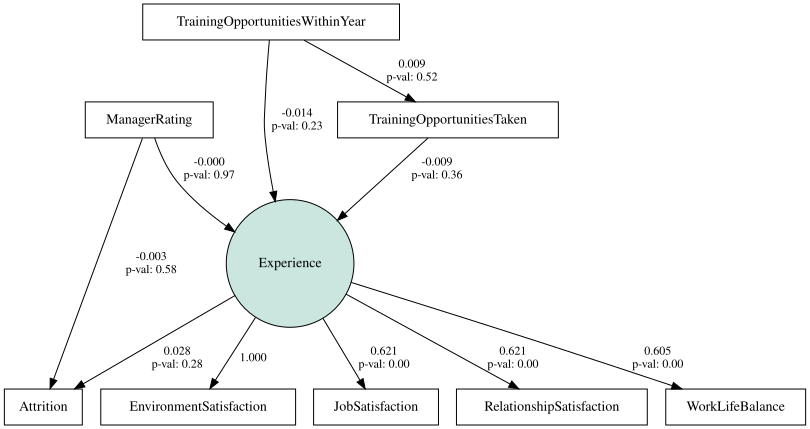

In [ ]:
from semopy import semplot
semplot(model, "sem_model.png")    #將結構方程模型的路徑關係輸出成圖片

In [ ]:
df.to_csv("HRV_all.csv", index=False)  #匯出最終分析用資料集

In [ ]:
numeric_data = df.select_dtypes(include=['number'])  #選出所有的數值型資料

In [ ]:
correlation_matrix = numeric_data.corr()  #計算變數間的相關係數矩陣
correlation_matrix

,Age,DistanceFromHome (KM),Salary,StockOptionLevel,Attrition,YearsAtCompany,YearsInMostRecentRole,YearsSinceLastPromotion,YearsWithCurrManager,ReviewYear,...,EnvironmentSatisfaction,JobSatisfaction,RelationshipSatisfaction,TrainingOpportunitiesWithinYear,TrainingOpportunitiesTaken,WorkLifeBalance,SelfRating,ManagerRating,YearWeight,Experience
Age,1.000000,0.015478,0.416135,0.045694,-0.372149,0.644249,0.407303,0.542996,0.447808,-0.030957,...,0.001642,0.006243,0.004933,-0.008589,0.000604,-0.002490,-0.004068,0.001279,-0.030957,-0.008498
DistanceFromHome (KM),0.015478,1.000000,0.074380,0.036548,-0.009133,-0.024365,-0.017381,-0.043226,0.007742,0.001695,...,0.003540,-0.011286,0.010385,-0.004069,-0.017748,0.006012,0.031431,0.025297,0.001695,0.003855
Salary,0.416135,0.074380,1.000000,0.006659,-0.211330,0.220986,0.110721,0.166570,0.120970,0.045747,...,-0.011796,0.005444,-0.000339,0.007682,0.010340,-0.001798,-0.001457,-0.001880,0.045747,-0.014681
StockOptionLevel,0.045694,0.036548,0.006659,1.000000,-0.164905,0.100888,0.057543,0.086255,0.100626,0.075193,...,-0.001350,-0.002938,0.008999,0.004156,0.002201,0.005916,0.014627,0.004748,0.075193,-0.002784
Attrition,-0.372149,-0.009133,-0.211330,-0.164905,1.000000,-0.689269,-0.460797,-0.617997,-0.458518,-0.320977,...,0.006519,0.012404,0.008720,-0.005892,-0.008893,0.003914,0.003234,-0.007046,-0.320977,0.046114
YearsAtCompany,0.644249,-0.024365,0.220986,0.100888,-0.689269,1.000000,0.639591,0.840938,0.646922,0.049691,...,0.010264,0.001974,0.005201,-0.000036,0.006581,0.008209,0.010970,0.017865,0.049691,-0.010733
YearsInMostRecentRole,0.407303,-0.017381,0.110721,0.057543,-0.460797,0.639591,1.000000,0.795342,0.395855,0.035029,...,0.010178,-0.002520,0.015262,0.001014,-0.004463,0.021769,0.020647,0.032038,0.035029,0.002780
YearsSinceLastPromotion,0.542996,-0.043226,0.166570,0.086255,-0.617997,0.840938,0.795342,1.000000,0.543702,0.058580,...,0.014351,-0.000156,0.002004,0.003987,-0.001009,0.016446,0.013634,0.020290,0.058580,-0.004478
YearsWithCurrManager,0.447808,0.007742,0.120970,0.100626,-0.458518,0.646922,0.395855,0.543702,1.000000,0.031035,...,0.018518,0.001821,0.007604,-0.000349,0.003387,-0.015416,0.004162,0.007659,0.031035,-0.003538
ReviewYear,-0.030957,0.001695,0.045747,0.075193,-0.320977,0.049691,0.035029,0.058580,0.031035,1.000000,...,-0.096524,-0.056191,-0.047250,0.002116,-0.022869,-0.025991,-0.032290,-0.024088,1.000000,-0.122246


In [ ]:
correlation_with_target = correlation_matrix['Attrition'].sort_values(ascending=False)  #找出與「離職 (Attrition)」相關性最高的變數並排序列出
print(correlation_with_target)

Attrition                          1.000000
Experience                         0.046114
JobSatisfaction                    0.012404
RelationshipSatisfaction           0.008720
EnvironmentSatisfaction            0.006519
WorkLifeBalance                    0.003914
SelfRating                         0.003234
TrainingOpportunitiesWithinYear   -0.005892
ManagerRating                     -0.007046
TrainingOpportunitiesTaken        -0.008893
DistanceFromHome (KM)             -0.009133
StockOptionLevel                  -0.164905
Salary                            -0.211330
New_Salary                        -0.215755
YearWeight                        -0.320977
ReviewYear                        -0.320977
Age                               -0.372149
YearsWithCurrManager              -0.458518
YearsInMostRecentRole             -0.460797
YearsSinceLastPromotion           -0.617997
YearsAtCompany                    -0.689269
Name: Attrition, dtype: float64


In [ ]:
cols = [
    'YearsWithCurrManager',
    'YearsInMostRecentRole',
    'YearsSinceLastPromotion'
]

avg_values = df.groupby('Attrition')[cols].mean()  #計算離職與未離職員工在指定年資欄位上的平均值
avg_values


,YearsWithCurrManager,YearsInMostRecentRole,YearsSinceLastPromotion
Attrition,,,
0.0,3.733664,3.778053,5.657503
1.0,1.019103,1.033763,1.497557


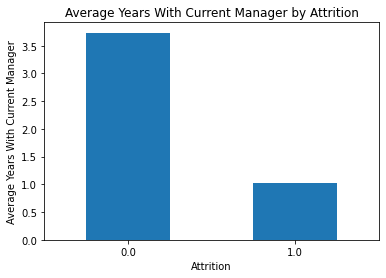

In [ ]:
#與現任主管共事年資」在離職/未離職間的長條圖比較
plt.figure()
avg_values['YearsWithCurrManager'].plot(kind='bar')             
plt.title('Average Years With Current Manager by Attrition')
plt.xlabel('Attrition')
plt.ylabel('Average Years With Current Manager')
plt.xticks(rotation=0)
plt.show()


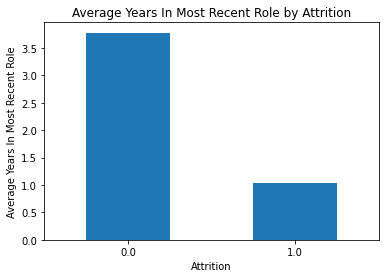

In [ ]:
plt.figure()
avg_values['YearsInMostRecentRole'].plot(kind='bar')
plt.title('Average Years In Most Recent Role by Attrition')
plt.xlabel('Attrition')
plt.ylabel('Average Years In Most Recent Role')
plt.xticks(rotation=0)
plt.show()


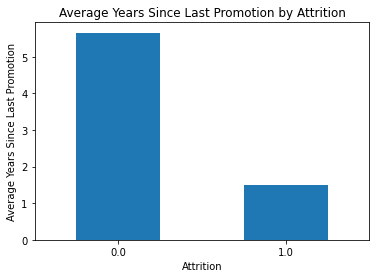

In [ ]:
plt.figure()
avg_values['YearsSinceLastPromotion'].plot(kind='bar')
plt.title('Average Years Since Last Promotion by Attrition')
plt.xlabel('Attrition')
plt.ylabel('Average Years Since Last Promotion')
plt.xticks(rotation=0)
plt.show()


<Figure size 576x360 with 0 Axes>

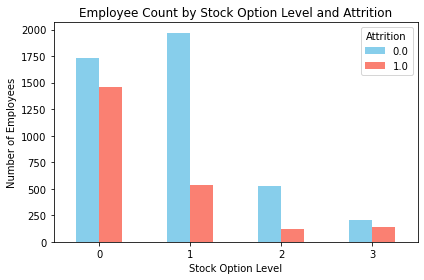

In [ ]:
stock_counts = df.groupby(['StockOptionLevel', 'Attrition']).size().unstack()  #股票選擇權

stock_counts

plt.figure(figsize=(8, 5))
stock_counts.plot(kind='bar', color=['skyblue', 'salmon'])

plt.title('Employee Count by Stock Option Level and Attrition')
plt.xlabel('Stock Option Level')
plt.ylabel('Number of Employees')
plt.xticks(rotation=0)
plt.legend(title='Attrition')
plt.tight_layout()
plt.show()


### Building AI Model

In [353]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler, OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib


In [354]:
df = pd.read_csv('HR_AIV3.csv')

In [ ]:
#定義不需要放入模型的欄位清單（如 ID、姓名、日期等）
drop_cols = ["EmployeeID" , "FirstName" , "LastName"  , "YearsInMostRecentRole", "StockOptionLevel", "HireDate" , "Salary" , "ReviewYear"]
#定義需要特別處理的特徵清單
process_cols = ["Age", "DistanceFromHome (KM)" , "ExperienceLevel" , "Salary" , "OverTime" , "Attrition"]
#定義已經處理好可直接使用的特徵清單
ready_cols = ["YearsSinceLastPromotion" , "ManagerRating", "YearsWithCurrManager" , "weighted_mean_emp" ,"TrainingOpportunitiesTaken" , "TrainingOpportunitiesWithinYear","Education_num" , "YearsAtCompany" ]
#定義需要進行類別編碼的特徵清單
classify_cols = ["Gender" , "BusinessTravel" , "Department" , "State" , "Ethnicity" , "EducationField","JobRole", "MaritalStatus" , "Education"  ]

In [356]:
df['ExperienceLevel']

0          Mid
1          Mid
2       Junior
3          Mid
4       Junior
         ...  
1271       Mid
1272       Mid
1273       Mid
1274       Mid
1275    Senior
Name: ExperienceLevel, Length: 1276, dtype: object

In [ ]:
# ExperienceLevel: ordinal encoding 序列編碼
df = df.drop(columns=drop_cols) #刪除不需要的欄位

# Age: categorize to over 30 and under 30
df['Age'] = df['Age'].apply(lambda x: 1 if x >= 30 else 0)  #將年齡二元化，1 for over30, 0 for under30

# DistanceFromHome: categorize based on mean
distance_mean = df['DistanceFromHome (KM)'].mean()
df['DistanceFromHome (KM)'] = df['DistanceFromHome (KM)'].apply(lambda x: 1 if x >= distance_mean else 0) #將通勤距離二元化：大於平均距離設為 1，小於平均距離設為 0

experience_encoder = OrdinalEncoder(categories=[['Junior', 'Mid', 'Senior']]) #將經驗等級進行「序數編碼 (Ordinal Encoding)」，依照初、中、高等級轉換為數值 0, 1, 2
df['ExperienceLevel'] = experience_encoder.fit_transform(df[['ExperienceLevel']])

# OverTime: encode Yes/No
df['OverTime'] = df['OverTime'].map({'Yes': 1, 'No': 0})

# Attrition (target): encode Yes=0, No=1
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

label_encoders = {} 
for col in classify_cols:
    le = LabelEncoder() #使用 LabelEncoder 將其餘類別文字欄位（如性別、部門、學歷等）自動轉換為數字標籤
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le #將編碼器存起來以備未來轉換使用

In [ ]:
# 切割訓練集/測試集與特徵標準化
# # 4. Train-Test Split
X = df.drop('ManagerRating', axis=1) #特徵變數（排除目標）
y = df['ManagerRating']              #目標變數（預測主管評分）

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) #將資料按照 8:2 的比例隨機切割為訓練集

# 5. NOW normalize Salary (AFTER split) 
scaler = StandardScaler() #薪資標準化處理
X_train['New_Salary'] = scaler.fit_transform(X_train[['New_Salary']])  # Fit on train only 以訓練集計算平均與標準差並轉換
X_test['New_Salary'] = scaler.transform(X_test[['New_Salary']])  # Transform test using train statistics 測試集僅套用訓練集的參數進行轉換（避免資料外洩）

# Check the results 印出切割後的資料維度與分佈狀況，確保切割正確
print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)
print("\nTraining set sample:")
print(X_train.head())
print("\nTarget distribution in training set:")
print(y_train.value_counts())
print("\nTarget distribution in test set:")
print(y_test.value_counts())

Training set shape: (1020, 19)
Test set shape: (256, 19)

Training set sample:
     weighted_mean_emp  Gender  Age  BusinessTravel  Department  \
984           3.250000       0    1               0           0   
415           3.375000       0    1               2           1   
780           3.310000       0    0               2           1   
919           3.337500       0    0               2           2   
96            3.333333       2    0               2           1   

     DistanceFromHome (KM)  State  Ethnicity  Education  EducationField  \
984                      1      0          1          0               2   
415                      1      0          0          0               7   
780                      0      0          6          2               5   
919                      1      1          3          0               4   
96                       0      0          6          0               5   

     JobRole  MaritalStatus  OverTime  Attrition  YearsAtCompany  \

In [ ]:
from sklearn.linear_model import LinearRegression # 載入線性迴歸模型
from sklearn.ensemble import RandomForestRegressor # 載入隨機森林迴歸模型
from sklearn.metrics import mean_squared_error # 載入均方誤差 (MSE) 評估指標

# 1. Train Linear Regression
print("="*50)
print("Training Linear Regression Model")
print("="*50)

log_reg = LinearRegression()
log_reg.fit(X_train, y_train)

# Predictions
y_pred_train_lr = log_reg.predict(X_train)
y_pred_test_lr = log_reg.predict(X_test)

# Evaluation
train_accuracy_lr = mean_squared_error(y_train, y_pred_train_lr)
test_accuracy_lr = mean_squared_error(y_test, y_pred_test_lr)

print(f"\nLogistic Regression - Training mse: {train_accuracy_lr:.4f}")
print(f"Logistic Regression - Test mse: {test_accuracy_lr:.4f}")

# 2. Train Random Forest
print("\n" + "="*50)
print("Training Random Forest Model")
print("="*50)

rf_model = RandomForestRegressor(n_estimators=100)
rf_model.fit(X_train, y_train)

# Predictions
y_pred_train_rf = rf_model.predict(X_train)
y_pred_test_rf = rf_model.predict(X_test)

# Evaluation
train_accuracy_rf = mean_squared_error(y_train, y_pred_train_rf)
test_accuracy_rf = mean_squared_error(y_test, y_pred_test_rf)

print(f"\nRandom Forest - Training mse: {train_accuracy_rf:.4f}")
print(f"Random Forest - Test mse: {test_accuracy_rf:.4f}")

# 3. Compare Models
print("\n" + "="*50)
print("Model Comparison")
print("="*50)
print(f"Logistic Regression - Test Accuracy: {test_accuracy_lr:.4f}")
print(f"Random Forest - Test Accuracy: {test_accuracy_rf:.4f}")

# Select best model based on test accuracy 比較兩個模型的數值
if test_accuracy_lr < test_accuracy_rf:  #MSE誤差數值越小越好，這裡將其當作Accuracy的遺留程式碼）
    best_model = log_reg  #若前者的值較大則選線性迴歸
    best_model_name = "Linear Regression"
    best_accuracy = test_accuracy_lr
else:
    best_model = rf_model #否則選隨機森林
    best_model_name = "Random Forest"
    best_accuracy = test_accuracy_rf

print(f"\nBest Model: {best_model_name} with Test Accuracy: {best_accuracy:.4f}")

# 4. Save the best model and scaler 將表現最佳的模型以及前面的標準化轉換器 (scaler) 儲存為 .pkl 檔案，方便未來佈署或重複使用
joblib.dump(best_model, 'best_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("\n" + "="*50)
print("Model and Scaler saved successfully!")
print("="*50)
print("Files saved:")
print("- best_model.pkl")
print("- scaler.pkl")

Training Logistic Regression Model...

Logistic Regression - Training mse: 0.3068
Logistic Regression - Test mse: 0.2858

Training Random Forest Model...

Random Forest - Training mse: 0.0458
Random Forest - Test mse: 0.3412

Model Comparison
Logistic Regression - Test Accuracy: 0.2858
Random Forest - Test Accuracy: 0.3412

Best Model: Random Forest with Test Accuracy: 0.3412

Model and Scaler saved successfully!
Files saved:
- best_model.pkl
- scaler.pkl


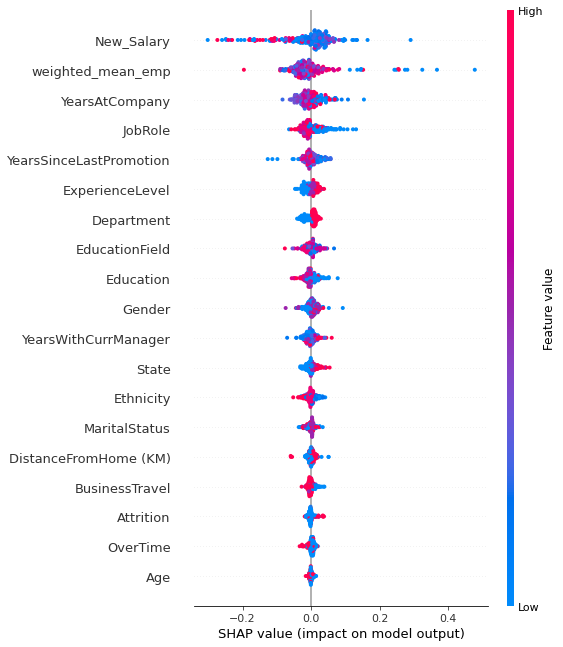

In [ ]:
explainer = shap.TreeExplainer(rf_model)     #建立針對 Random Forest 的 SHAP 解釋器
shap_values = explainer.shap_values(X_test)  #建立針對 Random Forest 的 SHAP 解釋器

shap.summary_plot(shap_values, X_test)       #繪製 SHAP 摘要圖，以視覺化呈現哪些特徵對「主管評分」的影響力最大以及其正負向關係